Import all the necessary packages 

In [6]:
# all the necessary pytorch packages
import torch 
import torch.nn as nn
import torch.optim as optim 
from torch.utils.data import DataLoader, Subset

# cross val
from sklearn.model_selection import StratifiedKFold

# hpo library
import optuna
from optuna.samplers import RandomSampler


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import json 
import random 

import os

import sys

import time
from pathlib import Path

# assume notebook being run from assignment folder
ASSIGNMENT_DIR = Path.cwd()
BASELINE_NOTEBOOK = ASSIGNMENT_DIR / "baseline.ipynb"
SUPPORT_DIR = ASSIGNMENT_DIR #/ "WF-data and support code"
FIGURE_DIR = ASSIGNMENT_DIR /"figures"

os.chdir(SUPPORT_DIR)

from support import load_dataset

device = ('mps' if torch.backends.mps.is_available()
          else 'cuda' if torch.cuda.is_available()
          else 'cpu')

Set the seeding to make the results reproducible 

In [9]:
SEED = 42

def set_seed(seed):
    ' make the randomness as reproducible as possible'
    random.seed(seed)
    np.random.seed(seed)

    # Pytorch cpu random gen
    torch.manual_seed(seed)

    # Pytorch gpu random gen, 
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
set_seed(SEED)

Find `CNN`, `train_one_epoch` and `evaluate` from the baseline solution. Don't run the full thing as this is all we need 

In [10]:
def find_baseline_def(marker):
    'execute one cell from baseline identified by a unique marker'

    # open the notebook as a json file 
    with open(BASELINE_NOTEBOOK) as f:
        baseline_nb = json.load(f)

    # look through every cell til we find the marker 
    for cell in baseline_nb["cells"]:
        # skip markdown cells
        if cell.get("cell_type") != "code":
            continue

        # join the list of strings to turn them back to pythn code    
        source = ''.join(cell.get("source", []))

        if marker in source:
            # run the selected cell in notebooks global namespace. 
            exec(source, globals())
            print(f'Loaded from baseline: {marker}')
            return 

# load all of the definitions
find_baseline_def('class CNN(nn.Module):')
find_baseline_def('def train_one_epoch')
find_baseline_def('def evaluate')



Loaded from baseline: class CNN(nn.Module):
Loaded from baseline: def train_one_epoch
Loaded from baseline: def evaluate


Load only the data needed for HPO

In [11]:

train_dataset, test_dataset = load_dataset()

# the integer class labels for each image type
labels = np.array(train_dataset.targets)

# the human readable class names
class_names = train_dataset.classes

We search over the following 5 hyperparameters:
- `learning rate`
- `batch rate`
- `base filters`
- `dropout`
- `hidden units`

The ranges were all centred (roughly) around the baseline model
This dictionary doesn't get used directly by Optuna. Just helps everyone see the search space (especially Ernst). 

In [12]:
SEARCH_SPACE_DESCRIPTION = {
    # Use log uniform as learning rates often differ by larger rates
    "lr": 'log-uniform [1e-4, 3e-3]',

    # larger than 32 doesnt really make sense as only 136 image
    "batch_size": '[8, 16, 32]',

    # this is converted to conv_channels = (base_fitlers, 2*base_filters)
    'base_filters': '[16, 32, 48, 64]',

    # no dropout may overfit badly so dont go to 0
    'dropout': 'uniform [0.1, 0.6]',

    # size of layer after conv 
    'hidden': '[64, 128, 256]'
}

SEARCH_SPACE_DESCRIPTION

{'lr': 'log-uniform [1e-4, 3e-3]',
 'batch_size': '[8, 16, 32]',
 'base_filters': '[16, 32, 48, 64]',
 'dropout': 'uniform [0.1, 0.6]',
 'hidden': '[64, 128, 256]'}

Turn these hyperparameters into arguments 

In [14]:
def make_baseline_config(params):
    '''convert 5 sampled HPO values into the arguments for baseline.CNN'''
    base_filters = int(params['base_filters'])
    return {'lr': float(params['lr']),
            'batch_size': int(params['batch_size']),
             'base_filters': base_filters,
              'dropout': float(params['dropout']),
               'hidden': int(params['hidden']),
                'conv_channels': (base_filters, 2*base_filters) }

For each sampled configuration, we train 5 fresh models
- four folds for training 
- one for validation

In [15]:
def calculate_cv(config, trial_number = None):
    '''calculate the 5 fold cross validation score for one hyper parameter setting'''

    fold_scores = []
    fold_results = []
    # go thru all 5 folds for this one config
    for fold_number, (train_idx, val_idx) in enumerate(splits, start=1):

        set_seed(SEED +  fold_number)

        # create fold specific datasets w/o copying image tensors
        trainset_CV = Subset(train_dataset, train_idx)
        valset_CV = Subset(train_dataset, val_idx)

        print('Training fold size:', len(trainset_CV))
        print('Validation fold size:', len(valset_CV))

        # create data loader for this fold
        train_loader = DataLoader(dataset = trainset_CV,
                                  batch_size= config['batch_size'],
                                  shuffle = True)
        
        val_loader = DataLoader(dataset = valset_CV, 
                                batch_size= config['batch_size'],
                                shuffle = False)

        # define new model, loss func, optimizer for every fold
        model_CV = CNN(
            conv_channels = config['conv_channels'],
            hidden = config['hidden'],
            dropout = config['dropout'],
        ).to(device)

        # loss func for classification of logits
        criterion = nn.CrossEntropyLoss()

        # same as baseline
        optimizer = optim.Adam(model_CV.parameters(), lr = config['lr'])

        best_val_acc = 0.0
        best_epoch = 0

        # train the model for this fold 
        for epoch in range(1, CV_EPOCHS + 1):
            train_loss, train_acc = train_one_epoch(model_CV, train_loader,
                                                    optimizer,
                                                    criterion, device)
            val_loss, val_acc = evaluate(model_CV, val_loader, 
                                                criterion, device)
            print("Epoch:", epoch)
            print("Train Loss:", train_loss)
            print("Train accuracy:", 100.0 * train_acc)
            print("Validation Loss:", val_loss)
            print("Validation accuracy:", 100.0 * val_acc)

            # use best validation acc reached during this fold 
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_epoch = epoch
                best_train_loss = train_loss
                best_val_loss = val_loss

        print('Best validation accuracy in this fold', 100*best_val_acc)
        print('Best epoch in the fold', best_epoch)

        fold_scores.append(best_val_acc)

        
        fold_results.append({
            "trial": trial_number,
            "fold": fold_number,
            "best_val_acc": best_val_acc,
            "best_epoch": best_epoch,
            "best_train_loss": best_train_loss,
            "best_val_loss": best_val_loss,
            "lr": config["lr"],
            "batch_size": config["batch_size"],
            "base_filters": config["base_filters"],
            "conv_channels": str(config["conv_channels"]),
            "dropout": config["dropout"],
            "hidden": config["hidden"],
        })
    mean_CVscore = float(np.mean(fold_scores))
    std_CVscore = float(np.std(fold_scores))

    print("Mean CV accuracy:", mean_CVscore)
    print("Standard deviation CV accuracy:", std_CVscore)

    return mean_CVscore, std_CVscore, fold_scores, fold_results

Random search with 5 fold cross validation 

In [16]:
sampler = RandomSampler(seed = SEED)

# default values 
# total fold models trained = TRIALS * SPLITS
N_TRIALS = 10 
CV_EPOCHS = 10
N_SPLITS = 5

# keeps the ng/ok balance similar 
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state= SEED)
splits = list(cv.split(np.zeros(len(labels)), labels))

# print the validation class counts to confimr the folds are balanced
for fold, (_, val_idx) in enumerate(splits, start=1):
    fold_labels = labels[val_idx]
    counts = {class_names[i]: int((fold_labels == i).sum()) for i in range(len(class_names))}
    print(f"Fold {fold} validation counts:", counts)


Fold 1 validation counts: {'ng': 14, 'ok': 14}
Fold 2 validation counts: {'ng': 14, 'ok': 13}
Fold 3 validation counts: {'ng': 14, 'ok': 13}
Fold 4 validation counts: {'ng': 13, 'ok': 14}
Fold 5 validation counts: {'ng': 13, 'ok': 14}


In [17]:
def sample_config(trial):
    """Sample five hyperparameters and convert them to baseline-compatible config."""
    # trial.suggest_ is how Optuna chooses values
    # with RandomSampler, these choices are random within the specified spaces
    params = {
        "lr": trial.suggest_float("lr", 1e-4, 3e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [8, 16, 32]),
        "base_filters": trial.suggest_categorical("base_filters", [16, 32, 48, 64]),
        "dropout": trial.suggest_float("dropout", 0.10, 0.60),
        "hidden": trial.suggest_categorical("hidden", [64, 128, 256]),
    }

    # convert the five sampled values into the exact arguments needed by the
    # baseline CNN and training code
    return make_baseline_config(params)


# detailed: one row per trial per fold
all_trial_fold_results = []

def objective(trial):
    config = sample_config(trial)

    print("NEW RANDOM SEARCH ITERATION:", trial.number)
    print('Hyperparameters:', config)

    # calculate 5 fold cv score for this random config
    mean_acc, std_acc, fold_scores, fold_results = calculate_cv(config, trial_number= trial.number)

    # store fold levels results for extraction 
    all_trial_fold_results.extend(fold_results)

    # user_attrs are extra values saved inside the Optuna trial need for df later
    trial.set_user_attr("mean_val_acc", mean_acc)
    trial.set_user_attr("std_val_acc", std_acc)
    trial.set_user_attr("fold_scores", fold_scores)

    print(f"Trial {trial.number}: mean val acc = {mean_acc:.3f} +/- {std_acc:.3f}")
    return mean_acc

In [18]:
study = optuna.create_study(
    # want highest possible validation accuracy
    direction = 'maximize',
    sampler = RandomSampler(seed=SEED),
    study_name="random_search_5fold"
)

# run this search and take time
tic = time.perf_counter()
study.optimize(objective, n_trials= N_TRIALS)
toc = time.perf_counter()

print("\nBest trial:", study.best_trial.number)
print("Best mean validation accuracy:", study.best_value)
print("Best hyperparameters:", study.best_params)
print("Best baseline config:", make_baseline_config(study.best_params))
print("Total time passed:", toc - tic, "seconds")

[I 2026-06-02 14:44:49,470] A new study created in memory with name: random_search_5fold


NEW RANDOM SEARCH ITERATION: 0
Hyperparameters: {'lr': 0.0003574712922600243, 'batch_size': 8, 'base_filters': 64, 'dropout': 0.40055750587160444, 'hidden': 256, 'conv_channels': (64, 128)}
Training fold size: 108
Validation fold size: 28
Epoch: 1
Train Loss: 0.6960184000156544
Train accuracy: 46.2962962962963
Validation Loss: 0.6926909770284381
Validation accuracy: 50.0
Epoch: 2
Train Loss: 0.695558609785857
Train accuracy: 47.22222222222222
Validation Loss: 0.6922000987189156
Validation accuracy: 50.0
Epoch: 3
Train Loss: 0.6931432706338388
Train accuracy: 48.148148148148145
Validation Loss: 0.6898097991943359
Validation accuracy: 50.0
Epoch: 4
Train Loss: 0.68995291656918
Train accuracy: 53.70370370370371
Validation Loss: 0.681492166859763
Validation accuracy: 82.14285714285714
Epoch: 5
Train Loss: 0.6586694849861993
Train accuracy: 69.44444444444444
Validation Loss: 0.6047675950186593
Validation accuracy: 64.28571428571429
Epoch: 6
Train Loss: 0.6021573786382322
Train accuracy: 70.

[I 2026-06-02 15:00:13,012] Trial 0 finished with value: 0.8230158730158731 and parameters: {'lr': 0.0003574712922600243, 'batch_size': 8, 'base_filters': 64, 'dropout': 0.40055750587160444, 'hidden': 256}. Best is trial 0 with value: 0.8230158730158731.


Epoch: 10
Train Loss: 0.5881944566691687
Train accuracy: 66.97247706422019
Validation Loss: 0.43727098019034777
Validation accuracy: 88.88888888888889
Best validation accuracy in this fold 88.88888888888889
Best epoch in the fold 10
Mean CV accuracy: 0.8230158730158731
Standard deviation CV accuracy: 0.060166431173082395
Trial 0: mean val acc = 0.823 +/- 0.060
NEW RANDOM SEARCH ITERATION: 1
Hyperparameters: {'lr': 0.0016967533607196547, 'batch_size': 8, 'base_filters': 32, 'dropout': 0.40592644736118977, 'hidden': 256, 'conv_channels': (32, 64)}
Training fold size: 108
Validation fold size: 28
Epoch: 1
Train Loss: 0.6912380501076028
Train accuracy: 54.629629629629626
Validation Loss: 0.6939769812992641
Validation accuracy: 50.0
Epoch: 2
Train Loss: 0.6940583255555894
Train accuracy: 49.074074074074076
Validation Loss: 0.6937510967254639
Validation accuracy: 50.0
Epoch: 3
Train Loss: 0.6940971944067214
Train accuracy: 50.0
Validation Loss: 0.6934860944747925
Validation accuracy: 50.0
Ep

[I 2026-06-02 15:13:50,388] Trial 1 finished with value: 0.5074074074074074 and parameters: {'lr': 0.0016967533607196547, 'batch_size': 8, 'base_filters': 32, 'dropout': 0.40592644736118977, 'hidden': 256}. Best is trial 0 with value: 0.8230158730158731.


...

Epoch: 10
Train Loss: 0.6915051663687469
Train accuracy: 55.04587155963303
Validation Loss: 0.691985997888777
Validation accuracy: 48.148148148148145
Best validation accuracy in this fold 48.148148148148145
Best epoch in the fold 1
Mean CV accuracy: 0.6555555555555556
Standard deviation CV accuracy: 0.135375310240719
Trial 7: mean val acc = 0.656 +/- 0.135
NEW RANDOM SEARCH ITERATION: 8
Hyperparameters: {'lr': 0.0005917520523090669, 'batch_size': 8, 'base_filters': 32, 'dropout': 0.5537832369630465, 'hidden': 256, 'conv_channels': (32, 64)}
Training fold size: 108
Validation fold size: 28
Epoch: 1
Train Loss: 0.7025351700959382
Train accuracy: 52.77777777777778
Validation Loss: 0.695857116154262
Validation accuracy: 50.0
Epoch: 2
Train Loss: 0.7006689884044506
Train accuracy: 48.148148148148145
Validation Loss: 0.6929354327065604
Validation accuracy: 50.0
Epoch: 3
Train Loss: 0.6981628183965329
Train accuracy: 49.074074074074076
Validation Loss: 0.692778970514025
Validation accuracy: 5

[I 2026-06-02 16:42:01,391] Trial 8 finished with value: 0.7050264550264551 and parameters: {'lr': 0.0005917520523090669, 'batch_size': 8, 'base_filters': 32, 'dropout': 0.5537832369630465, 'hidden': 256}. Best is trial 3 with value: 0.8232804232804233.


Epoch: 10
Train Loss: 0.6927877741122465
Train accuracy: 50.45871559633027
Validation Loss: 0.6935947581573769
Validation accuracy: 48.148148148148145
Best validation accuracy in this fold 81.48148148148148
Best epoch in the fold 7
Mean CV accuracy: 0.7050264550264551
Standard deviation CV accuracy: 0.11605889755840322
Trial 8: mean val acc = 0.705 +/- 0.116
NEW RANDOM SEARCH ITERATION: 9
Hyperparameters: {'lr': 0.00021775224101934097, 'batch_size': 16, 'base_filters': 16, 'dropout': 0.5018360384495573, 'hidden': 128, 'conv_channels': (16, 32)}
Training fold size: 108
Validation fold size: 28
Epoch: 1
Train Loss: 0.6937572095129225
Train accuracy: 50.92592592592593
Validation Loss: 0.6930684958185468
Validation accuracy: 50.0
Epoch: 2
Train Loss: 0.6912197868029276
Train accuracy: 50.0
Validation Loss: 0.6929544976779393
Validation accuracy: 50.0
Epoch: 3
Train Loss: 0.69436173748087
Train accuracy: 50.92592592592593
Validation Loss: 0.6927920409611293
Validation accuracy: 50.0
Epoch: 

[I 2026-06-02 16:53:13,007] Trial 9 finished with value: 0.6460317460317461 and parameters: {'lr': 0.00021775224101934097, 'batch_size': 16, 'base_filters': 16, 'dropout': 0.5018360384495573, 'hidden': 128}. Best is trial 3 with value: 0.8232804232804233.


Epoch: 10
Train Loss: 0.6920614526906145
Train accuracy: 53.21100917431193
Validation Loss: 0.6925970801600704
Validation accuracy: 48.148148148148145
Best validation accuracy in this fold 48.148148148148145
Best epoch in the fold 1
Mean CV accuracy: 0.6460317460317461
Standard deviation CV accuracy: 0.12259157640480109
Trial 9: mean val acc = 0.646 +/- 0.123

Best trial: 3
Best mean validation accuracy: 0.8232804232804233
Best hyperparameters: {'lr': 0.00028180680291847244, 'batch_size': 16, 'base_filters': 64, 'dropout': 0.22938999080000846, 'hidden': 64}
Best baseline config: {'lr': 0.00028180680291847244, 'batch_size': 16, 'base_filters': 64, 'dropout': 0.22938999080000846, 'hidden': 64, 'conv_channels': (64, 128)}
Total time passed: 7703.535942699993 seconds


Save all the figures and results 

In [19]:
# convert the study into a df each row represents one random search
trials_df = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs", "state"))

# convert manually collected fold details into a table each row reprentes one random search
folds_df = pd.DataFrame(all_trial_fold_results)

# save the files
trials_path = ASSIGNMENT_DIR / "random_search_results/random_search_trials.csv"
folds_path = ASSIGNMENT_DIR / "random_search_results/random_search_folds.csv"
best_config_path = ASSIGNMENT_DIR / "random_search_results/best_random_search_config.json"

trials_df.to_csv(trials_path, index=False)
folds_df.to_csv(folds_path, index=False)

# convert  best Optuna params into format needed by the baseline
best_baseline_config = make_baseline_config(study.best_params)

#  JSON file records the best result 
best_config = {
    "best_trial": study.best_trial.number,
    "mean_validation_accuracy": study.best_value,
    "five_hyperparameters": study.best_params,
    "baseline_model_arguments": {
        "conv_channels": best_baseline_config["conv_channels"],
        "hidden": best_baseline_config["hidden"],
        "dropout": best_baseline_config["dropout"],
    },
    "optimizer_arguments": {
        "lr": best_baseline_config["lr"],
    },
    "data_loader_arguments": {
        "batch_size": best_baseline_config["batch_size"],
    },
    "n_trials": N_TRIALS,
    "cv_epochs": CV_EPOCHS,
    "n_splits": N_SPLITS,
    "search_space": SEARCH_SPACE_DESCRIPTION,
}

# save the best configuration in a structured format
with open(best_config_path, "w") as f:
    json.dump(best_config, f, indent=2)

# show the best trials directly in the notebook
display(trials_df.sort_values("value", ascending=False).head(10))

,number,value,params_base_filters,params_batch_size,params_dropout,params_hidden,params_lr,user_attrs_fold_scores,user_attrs_mean_val_acc,user_attrs_std_val_acc,state
3,3,0.823280,64,16,0.229390,64,0.000282,"[0.8571428571428571, 0.7777777777777778, 0.740...",0.823280,0.064246,COMPLETE
0,0,0.823016,64,8,0.400558,256,0.000357,"[0.8928571428571429, 0.7407407407407407, 0.777...",0.823016,0.060166,COMPLETE
5,5,0.808730,64,16,0.137275,64,0.000375,"[0.8214285714285714, 0.7777777777777778, 0.740...",0.808730,0.063929,COMPLETE
4,4,0.801058,16,16,0.144246,256,0.000642,"[0.8571428571428571, 0.7407407407407407, 0.777...",0.801058,0.061120,COMPLETE
8,8,0.705026,32,8,0.553783,256,0.000592,"[0.8214285714285714, 0.6296296296296297, 0.518...",0.705026,0.116059,COMPLETE
2,2,0.677249,48,8,0.132526,128,0.000472,"[0.5714285714285714, 0.7407407407407407, 0.777...",0.677249,0.110124,COMPLETE
7,7,0.655556,16,16,0.480393,128,0.000288,"[0.5, 0.7407407407407407, 0.7777777777777778, ...",0.655556,0.135375,COMPLETE
9,9,0.646032,16,16,0.501836,128,0.000218,"[0.7857142857142857, 0.7407407407407407, 0.703...",0.646032,0.122592,COMPLETE
6,6,0.566402,16,8,0.531552,64,0.000102,"[0.5357142857142857, 0.5185185185185185, 0.740...",0.566402,0.087423,COMPLETE
1,1,0.507407,32,8,0.405926,256,0.001697,"[0.5, 0.5185185185185185, 0.48148148148148145,...",0.507407,0.014815,COMPLETE


Plots for the report 

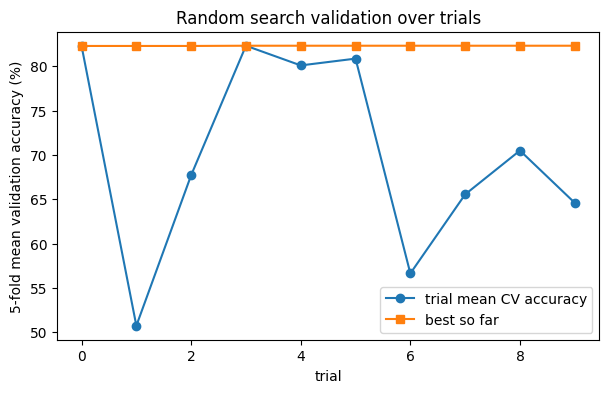

In [21]:
# sort by the numbers in which optuna ran them 
plot_df = trials_df.sort_values("number").copy()

plot_df['best_so_far'] = plot_df['value'].cummax()

plt.figure(figsize=(7,4))

# the raw sscore for each individual trail 
plt.plot(plot_df['number'], plot_df['value']*100, marker = 'o', label = 'trial mean CV accuracy')

# run best score found so far
plt.plot(plot_df['number'], plot_df['best_so_far']*100, marker = 's', label = 'best so far')
plt.xlabel('trial')
plt.ylabel('5-fold mean validation accuracy (%)')
plt.title('Random search validation over trials')
plt.legend()

# save the fig
curve_path = ASSIGNMENT_DIR / "random_search_results/random_search_validation_curve.png" #FIGURE_DIR/'random_search/random_search_validation_curve.png'
plt.savefig(curve_path, bbox_inches = 'tight', dpi = 150)
plt.show()

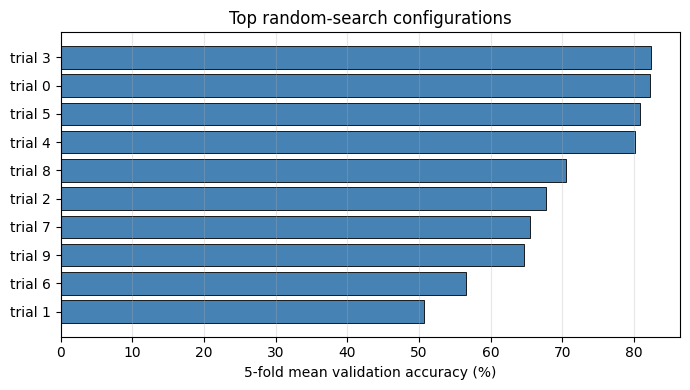

Saved: c:\Users\Ernst\OneDrive\Documenten\AI&ES TUe Year 1\Q4\Decision Making\Assignment 2\DMAI_assignment_2 copy\DMAI_assignment_2 copy\WF-data and support code\random_search_results\random_search_top_configs.png


In [22]:
# select the ten highest scoring trials
top_df = trials_df.sort_values("value", ascending=False).head(10).copy()

# readable labels for y axis
top_df["label"] = top_df["number"].apply(lambda n: f"trial {int(n)}")

plt.figure(figsize=(7, 4))

# horizontal barchat for final results
plt.barh(top_df["label"], top_df["value"] * 100, color="steelblue", edgecolor="black", linewidth=0.6)

# best trial at the top 
plt.gca().invert_yaxis()
plt.xlabel("5-fold mean validation accuracy (%)")
plt.title("Top random-search configurations")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
# save 
top_path = ASSIGNMENT_DIR / "random_search_results/random_search_top_configs.png" #FIGURE_DIR / "random_search/random_search_top_configs.png"
plt.savefig(top_path, bbox_inches="tight", dpi=150)
plt.show()
print("Saved:", top_path)


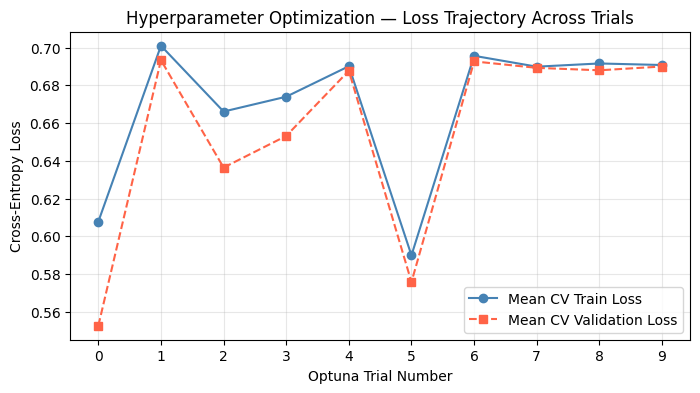

In [28]:
# Group fold dataframe by the trial number and calculate the mean losses
trial_losses = folds_df.groupby("trial")[["best_train_loss", "best_val_loss"]].mean().reset_index()

# Plot the loss values over the progression of the trials
plt.figure(figsize=(8, 4))
plt.plot(trial_losses["trial"], trial_losses["best_train_loss"], label="Mean CV Train Loss", marker='o', color="steelblue")
plt.plot(trial_losses["trial"], trial_losses["best_val_loss"], label="Mean CV Validation Loss", marker='s', color="tomato", linestyle="--")

plt.xlabel("Optuna Trial Number")
plt.ylabel("Cross-Entropy Loss")
plt.title("Hyperparameter Optimization — Loss Trajectory Across Trials")
plt.xticks(trial_losses["trial"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("../figures/hpo_loss_curve.png", bbox_inches="tight", dpi=150)
plt.show()

Retrain CNN model on the full training set using the best Random Search parameters

In [38]:
FINAL_EPOCHS = 30

train_loader = DataLoader(train_dataset, batch_size=best_baseline_config['batch_size'], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=best_baseline_config['batch_size'], shuffle=False)

final_random_model = CNN(
    conv_channels=best_baseline_config['conv_channels'],
    hidden=best_baseline_config['hidden'],
    dropout=best_baseline_config['dropout']
).to(device)

optimizer = optim.Adam(final_random_model.parameters(), lr=best_baseline_config["lr"])
criterion = nn.CrossEntropyLoss()

train_loss_history = []
train_acc_history = []
test_loss_history = []
test_acc_history = []

for epoch in range(1, FINAL_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(final_random_model, train_loader, optimizer, criterion, device)

    test_loss, test_acc = evaluate(final_random_model, test_loader, criterion, device)

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)

    print(f"epoch {epoch+1:02d} | train loss {train_loss:.4f} acc {train_acc:.3f}")

torch.save(final_random_model.state_dict(), ASSIGNMENT_DIR / "model_with_random_search.pth")

epoch 02 | train loss 0.7018 acc 0.500
epoch 03 | train loss 0.6940 acc 0.500
epoch 04 | train loss 0.6941 acc 0.500
epoch 05 | train loss 0.6939 acc 0.500
epoch 06 | train loss 0.6939 acc 0.500
epoch 07 | train loss 0.6938 acc 0.500
epoch 08 | train loss 0.6934 acc 0.500
epoch 09 | train loss 0.6930 acc 0.500
epoch 10 | train loss 0.6915 acc 0.500
epoch 11 | train loss 0.6948 acc 0.500
epoch 12 | train loss 0.6852 acc 0.507
epoch 13 | train loss 0.6817 acc 0.603
epoch 14 | train loss 0.6498 acc 0.662
epoch 15 | train loss 0.5622 acc 0.706
epoch 16 | train loss 0.5249 acc 0.721
epoch 17 | train loss 0.4294 acc 0.772
epoch 18 | train loss 0.5024 acc 0.750
epoch 19 | train loss 0.4933 acc 0.801
epoch 20 | train loss 0.4937 acc 0.794
epoch 21 | train loss 0.4605 acc 0.824
epoch 22 | train loss 0.4270 acc 0.824
epoch 23 | train loss 0.3763 acc 0.868
epoch 24 | train loss 0.3962 acc 0.816
epoch 25 | train loss 0.4245 acc 0.868
epoch 26 | train loss 0.3518 acc 0.853
epoch 27 | train loss 0.2

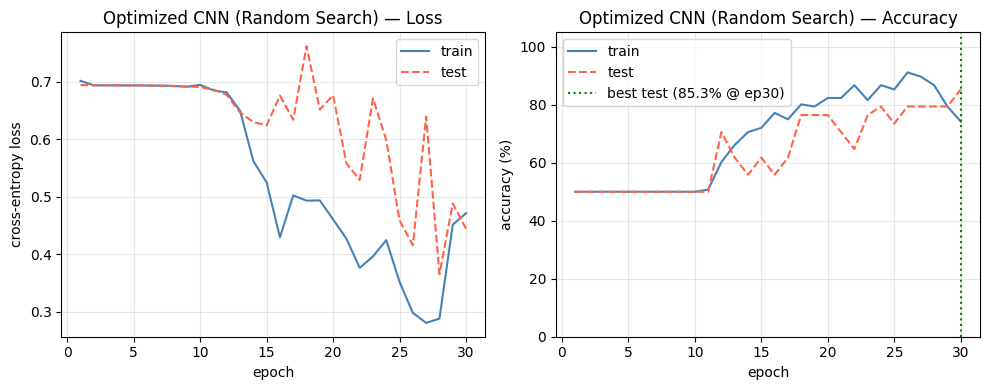

Saved optimized_random_search_learning_curves.png


In [39]:
epochs_range = range(1, len(train_loss_history) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(epochs_range, train_loss_history, label="train", color="steelblue")
ax1.plot(epochs_range, test_loss_history,  label="test",  color="tomato", linestyle="--")
ax1.set_xlabel("epoch")
ax1.set_ylabel("cross-entropy loss")
ax1.set_title("Optimized CNN (Random Search) — Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [a * 100 for a in train_acc_history], label="train", color="steelblue")
ax2.plot(epochs_range, [a * 100 for a in test_acc_history],  label="test",  color="tomato", linestyle="--")

best_opt_epoch = int(np.argmax(test_acc_history)) + 1
best_opt_acc   = max(test_acc_history) * 100

ax2.axvline(best_opt_epoch, color="green", linestyle=":", linewidth=1.5, 
            label=f"best test ({best_opt_acc:.1f}% @ ep{best_opt_epoch})")
ax2.set_xlabel("epoch")
ax2.set_ylabel("accuracy (%)")
ax2.set_title("Optimized CNN (Random Search) — Accuracy")
ax2.set_ylim(0, 105)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../optimized_random_search_learning_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved optimized_random_search_learning_curves.png")

## TPE Search
Swapping the sampler to change from random search to a more sophisticated Bayesion optimization method: TPE Search.

In [53]:
def sample_config(trial):
    """Sample five hyperparameters and convert them to baseline-compatible config."""
    # trial.suggest_ is how Optuna chooses values
    # with RandomSampler, these choices are random within the specified spaces
    params = {
        "lr": trial.suggest_float("lr", 1e-4, 3e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [8, 16, 32]),
        "base_filters": trial.suggest_categorical("base_filters", [16, 32, 48, 64]),
        "dropout": trial.suggest_float("dropout", 0.10, 0.60),
        "hidden": trial.suggest_categorical("hidden", [64, 128, 256]),
    }

    # convert the five sampled values into the exact arguments needed by the
    # baseline CNN and training code
    return make_baseline_config(params)


# detailed: one row per trial per fold
all_trial_fold_results = []

# Increase the number of epochs to allow for TPE to exploit patterns
global CV_EPOCHS
CV_EPOCHS = 30

def objective(trial):
    config = sample_config(trial)

    print("NEW RANDOM SEARCH ITERATION:", trial.number)
    print('Hyperparameters:', config)

    # calculate 5 fold cv score for this random config
    mean_acc, std_acc, fold_scores, fold_results = calculate_cv(config, trial_number= trial.number)

    # store fold levels results for extraction 
    all_trial_fold_results.extend(fold_results)

    # user_attrs are extra values saved inside the Optuna trial need for df later
    trial.set_user_attr("mean_val_acc", mean_acc)
    trial.set_user_attr("std_val_acc", std_acc)
    trial.set_user_attr("fold_scores", fold_scores)

    print(f"Trial {trial.number}: mean val acc = {mean_acc:.3f} +/- {std_acc:.3f}")
    return mean_acc

In [54]:
from optuna.samplers import TPESampler

In [55]:
study_sophisticated = optuna.create_study(
    # want highest possible validation accuracy
    direction = 'maximize',
    sampler = TPESampler(seed=SEED, n_startup_trials=3),
    study_name="tpe_search_5fold"
)

# run this search and take time
tic = time.perf_counter()
study_sophisticated.optimize(objective, n_trials= N_TRIALS)
toc = time.perf_counter()

print("\nBest Sophisticated Trial:", study_sophisticated.best_trial.number)
print("Best mean validation accuracy:", study_sophisticated.best_value)
print("Best hyperparameters:", study_sophisticated.best_params)
print("Best baseline config:", make_baseline_config(study_sophisticated.best_params))
print("Total time passed:", toc - tic, "seconds")   

[I 2026-06-02 22:53:05,592] A new study created in memory with name: tpe_search_5fold


NEW RANDOM SEARCH ITERATION: 0
Hyperparameters: {'lr': 0.0003574712922600243, 'batch_size': 8, 'base_filters': 64, 'dropout': 0.40055750587160444, 'hidden': 256, 'conv_channels': (64, 128)}
Training fold size: 108
Validation fold size: 28
Epoch: 1
Train Loss: 0.6960184000156544
Train accuracy: 46.2962962962963
Validation Loss: 0.6926909770284381
Validation accuracy: 50.0
Epoch: 2
Train Loss: 0.695558609785857
Train accuracy: 47.22222222222222
Validation Loss: 0.6922000987189156
Validation accuracy: 50.0
Epoch: 3
Train Loss: 0.6931432706338388
Train accuracy: 48.148148148148145
Validation Loss: 0.6898097991943359
Validation accuracy: 50.0
Epoch: 4
Train Loss: 0.68995291656918
Train accuracy: 53.70370370370371
Validation Loss: 0.681492166859763
Validation accuracy: 82.14285714285714
Epoch: 5
Train Loss: 0.6586694849861993
Train accuracy: 69.44444444444444
Validation Loss: 0.6047675950186593
Validation accuracy: 64.28571428571429
Epoch: 6
Train Loss: 0.6021573786382322
Train accuracy: 70.

[I 2026-06-02 23:28:02,310] Trial 0 finished with value: 0.9632275132275133 and parameters: {'lr': 0.0003574712922600243, 'batch_size': 8, 'base_filters': 64, 'dropout': 0.40055750587160444, 'hidden': 256}. Best is trial 0 with value: 0.9632275132275133.


Epoch: 30
Train Loss: 0.18696208838202538
Train accuracy: 89.90825688073394
Validation Loss: 0.1759904475054807
Validation accuracy: 92.5925925925926
Best validation accuracy in this fold 96.29629629629629
Best epoch in the fold 26
Mean CV accuracy: 0.9632275132275133
Standard deviation CV accuracy: 0.02343025378358151
Trial 0: mean val acc = 0.963 +/- 0.023
NEW RANDOM SEARCH ITERATION: 1
Hyperparameters: {'lr': 0.0016967533607196547, 'batch_size': 8, 'base_filters': 32, 'dropout': 0.40592644736118977, 'hidden': 256, 'conv_channels': (32, 64)}
Training fold size: 108
Validation fold size: 28
Epoch: 1
Train Loss: 0.6912380501076028
Train accuracy: 54.629629629629626
Validation Loss: 0.6939769812992641
Validation accuracy: 50.0
Epoch: 2
Train Loss: 0.6940583255555894
Train accuracy: 49.074074074074076
Validation Loss: 0.6937510967254639
Validation accuracy: 50.0
Epoch: 3
Train Loss: 0.6940971944067214
Train accuracy: 50.0
Validation Loss: 0.6934860944747925
Validation accuracy: 50.0
Epoc

[I 2026-06-03 00:00:12,978] Trial 1 finished with value: 0.5148148148148148 and parameters: {'lr': 0.0016967533607196547, 'batch_size': 8, 'base_filters': 32, 'dropout': 0.40592644736118977, 'hidden': 256}. Best is trial 0 with value: 0.9632275132275133.


...

Epoch: 30
Train Loss: 0.25571021772579317
Train accuracy: 91.74311926605505
Validation Loss: 0.150793325845842
Validation accuracy: 96.29629629629629
Best validation accuracy in this fold 96.29629629629629
Best epoch in the fold 19
Mean CV accuracy: 0.941005291005291
Standard deviation CV accuracy: 0.029832074833884552
Trial 7: mean val acc = 0.941 +/- 0.030
NEW RANDOM SEARCH ITERATION: 8
Hyperparameters: {'lr': 0.00024569338078370075, 'batch_size': 8, 'base_filters': 32, 'dropout': 0.42550790158579727, 'hidden': 256, 'conv_channels': (32, 64)}
Training fold size: 108
Validation fold size: 28
Epoch: 1
Train Loss: 0.7018185103381122
Train accuracy: 50.0
Validation Loss: 0.6933897733688354
Validation accuracy: 50.0
Epoch: 2
Train Loss: 0.6920812659793429
Train accuracy: 53.70370370370371
Validation Loss: 0.6927644780703953
Validation accuracy: 50.0
Epoch: 3
Train Loss: 0.6957139836417304
Train accuracy: 40.74074074074074
Validation Loss: 0.6922445808138166
Validation accuracy: 50.0
Epoch

[I 2026-06-03 03:42:12,700] Trial 8 finished with value: 0.9484126984126984 and parameters: {'lr': 0.00024569338078370075, 'batch_size': 8, 'base_filters': 32, 'dropout': 0.42550790158579727, 'hidden': 256}. Best is trial 0 with value: 0.9632275132275133.


Epoch: 30
Train Loss: 0.2734518895660519
Train accuracy: 89.90825688073394
Validation Loss: 0.13381670732741002
Validation accuracy: 96.29629629629629
Best validation accuracy in this fold 96.29629629629629
Best epoch in the fold 24
Mean CV accuracy: 0.9484126984126984
Standard deviation CV accuracy: 0.029766313606423716
Trial 8: mean val acc = 0.948 +/- 0.030
NEW RANDOM SEARCH ITERATION: 9
Hyperparameters: {'lr': 0.0010407425581904772, 'batch_size': 8, 'base_filters': 48, 'dropout': 0.2695070722352982, 'hidden': 256, 'conv_channels': (48, 96)}
Training fold size: 108
Validation fold size: 28
Epoch: 1
Train Loss: 0.728223756507591
Train accuracy: 50.92592592592593
Validation Loss: 0.6931412645748684
Validation accuracy: 50.0
Epoch: 2
Train Loss: 0.6930797519507231
Train accuracy: 50.92592592592593
Validation Loss: 0.69316223689488
Validation accuracy: 50.0
Epoch: 3
Train Loss: 0.6930747297075059
Train accuracy: 50.0
Validation Loss: 0.6931163753782
Validation accuracy: 50.0
Epoch: 4
Tr

[I 2026-06-03 04:15:32,755] Trial 9 finished with value: 0.7777777777777778 and parameters: {'lr': 0.0010407425581904772, 'batch_size': 8, 'base_filters': 48, 'dropout': 0.2695070722352982, 'hidden': 256}. Best is trial 0 with value: 0.9632275132275133.


Epoch: 30
Train Loss: 0.48377535211930583
Train accuracy: 71.55963302752293
Validation Loss: 0.36393372769708987
Validation accuracy: 81.48148148148148
Best validation accuracy in this fold 88.88888888888889
Best epoch in the fold 26
Mean CV accuracy: 0.7777777777777778
Standard deviation CV accuracy: 0.2146870629065102
Trial 9: mean val acc = 0.778 +/- 0.215

Best Sophisticated Trial: 0
Best mean validation accuracy: 0.9632275132275133
Best hyperparameters: {'lr': 0.0003574712922600243, 'batch_size': 8, 'base_filters': 64, 'dropout': 0.40055750587160444, 'hidden': 256}
Best baseline config: {'lr': 0.0003574712922600243, 'batch_size': 8, 'base_filters': 64, 'dropout': 0.40055750587160444, 'hidden': 256, 'conv_channels': (64, 128)}
Total time passed: 19346.957684299996 seconds


In [60]:
# convert the study into a df each row represents one random search
TPE_trials_df = study_sophisticated.trials_dataframe(attrs=("number", "value", "params", "user_attrs", "state"))

# convert manually collected fold details into a table each row reprentes one random search
TPE_folds_df = pd.DataFrame(all_trial_fold_results)

# save the files
trials_path_TPE = ASSIGNMENT_DIR / "TPE_search_results/TPE_30/TPE_search_trials.csv"
folds_path_TPE = ASSIGNMENT_DIR / "TPE_search_results/TPE_30/TPE_search_folds.csv"
best_config_path_TPE = ASSIGNMENT_DIR / "TPE_search_results/TPE_30/best_TPE_search_config.json"

TPE_trials_df.to_csv(trials_path_TPE, index=False)
TPE_folds_df.to_csv(folds_path_TPE, index=False)

# convert  best Optuna params into format needed by the baseline
best_baseline_config_TPE = make_baseline_config(study_sophisticated.best_params)

#  JSON file records the best result 
best_config_TPE = {
    "best_trial": study_sophisticated.best_trial.number,
    "mean_validation_accuracy": study_sophisticated.best_value,
    "five_hyperparameters": study_sophisticated.best_params,
    "baseline_model_arguments": {
        "conv_channels": best_baseline_config_TPE["conv_channels"],
        "hidden": best_baseline_config_TPE["hidden"],
        "dropout": best_baseline_config_TPE["dropout"],
    },
    "optimizer_arguments": {
        "lr": best_baseline_config_TPE["lr"],
    },
    "data_loader_arguments": {
        "batch_size": best_baseline_config_TPE["batch_size"],
    },
    "n_trials": N_TRIALS,
    "cv_epochs": CV_EPOCHS,
    "n_splits": N_SPLITS,
    "search_space": SEARCH_SPACE_DESCRIPTION,
}

# save the best configuration in a structured format
with open(best_config_path_TPE, "w") as f:
    json.dump(best_config_TPE, f, indent=2)

# show the best trials directly in the notebook
display(TPE_trials_df.sort_values("value", ascending=False).head(10))

,number,value,params_base_filters,params_batch_size,params_dropout,params_hidden,params_lr,user_attrs_fold_scores,user_attrs_mean_val_acc,user_attrs_std_val_acc,state
0,0,0.963228,64,8,0.400558,256,0.000357,"[0.9642857142857143, 0.9629629629629629, 0.925...",0.963228,0.023430,COMPLETE
2,2,0.955820,48,8,0.132526,128,0.000472,"[0.9642857142857143, 0.9629629629629629, 0.925...",0.955820,0.014956,COMPLETE
8,8,0.948413,32,8,0.425508,256,0.000246,"[0.9642857142857143, 0.9629629629629629, 0.888...",0.948413,0.029766,COMPLETE
6,6,0.941270,64,32,0.393389,64,0.000605,"[0.9285714285714286, 0.9629629629629629, 0.888...",0.941270,0.029383,COMPLETE
7,7,0.941005,16,16,0.143184,128,0.000347,"[0.9642857142857143, 0.9629629629629629, 0.888...",0.941005,0.029832,COMPLETE
4,4,0.926190,64,16,0.267398,256,0.000114,"[0.9642857142857143, 0.9259259259259259, 0.888...",0.926190,0.023845,COMPLETE
3,3,0.844974,64,32,0.566145,64,0.000113,"[0.9285714285714286, 0.8148148148148148, 0.777...",0.844974,0.055230,COMPLETE
9,9,0.777778,48,8,0.269507,256,0.001041,"[1.0, 0.5185185185185185, 0.5185185185185185, ...",0.777778,0.214687,COMPLETE
1,1,0.514815,32,8,0.405926,256,0.001697,"[0.5, 0.5185185185185185, 0.5185185185185185, ...",0.514815,0.007407,COMPLETE
5,5,0.500000,16,8,0.592617,256,0.002818,"[0.5, 0.48148148148148145, 0.48148148148148145...",0.500000,0.016563,COMPLETE


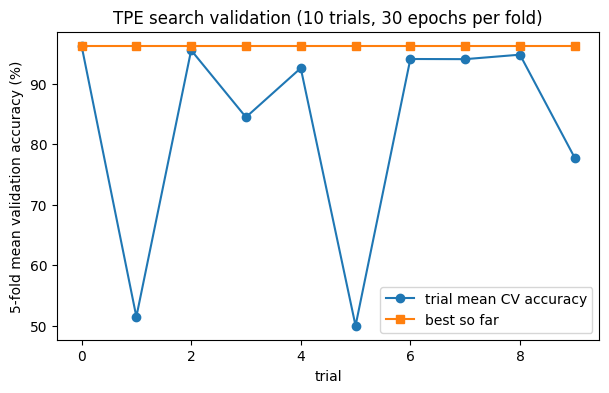

In [62]:
# sort by the numbers in which optuna ran them 
plot_df = TPE_trials_df.sort_values("number").copy()

plot_df['best_so_far'] = plot_df['value'].cummax()

plt.figure(figsize=(7,4))

# the raw sscore for each individual trail 
plt.plot(plot_df['number'], plot_df['value']*100, marker = 'o', label = 'trial mean CV accuracy')

# run best score found so far
plt.plot(plot_df['number'], plot_df['best_so_far']*100, marker = 's', label = 'best so far')
plt.xlabel('trial')
plt.ylabel('5-fold mean validation accuracy (%)')
plt.title('TPE search validation (10 trials, 30 epochs per fold)')
plt.legend()

# save the fig
curve_path = ASSIGNMENT_DIR / "TPE_search_results/TPE_search_validation_curve.png" # FIGURE_DIR/'TPE_search/TPE_search_validation_curve.png'
plt.savefig(curve_path, bbox_inches = 'tight', dpi = 150)
plt.show()

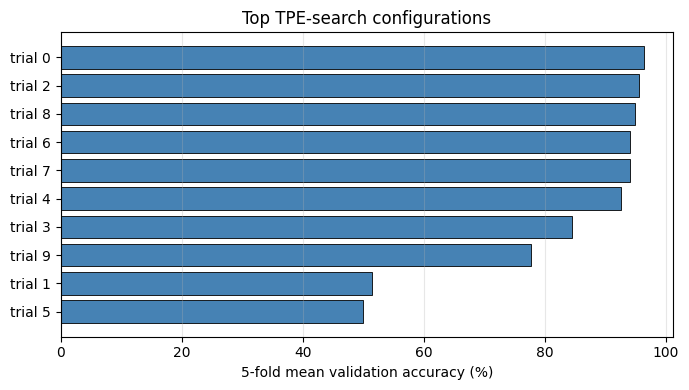

Saved: c:\Users\Ernst\OneDrive\Documenten\AI&ES TUe Year 1\Q4\Decision Making\Assignment 2\DMAI_assignment_2 copy\DMAI_assignment_2 copy\WF-data and support code\TPE_search_results\TPE_search_top_configs.png


In [63]:
# select the ten highest scoring trials
top_df = TPE_trials_df.sort_values("value", ascending=False).head(10).copy()

# readable labels for y axis
top_df["label"] = top_df["number"].apply(lambda n: f"trial {int(n)}")

plt.figure(figsize=(7, 4))

# horizontal barchat for final results
plt.barh(top_df["label"], top_df["value"] * 100, color="steelblue", edgecolor="black", linewidth=0.6)

# best trial at the top 
plt.gca().invert_yaxis()
plt.xlabel("5-fold mean validation accuracy (%)")
plt.title("Top TPE-search configurations")
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
# save 
top_path = ASSIGNMENT_DIR / "TPE_search_results/TPE_search_top_configs.png" # FIGURE_DIR / "random_search/random_search_top_configs.png"
plt.savefig(top_path, bbox_inches="tight", dpi=150)
plt.show()
print("Saved:", top_path)

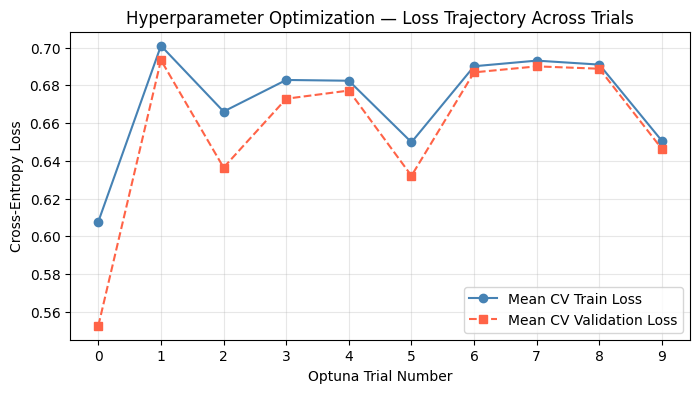

In [64]:
# Group fold dataframe by the trial number and calculate the mean losses
trial_losses = folds_df.groupby("trial")[["best_train_loss", "best_val_loss"]].mean().reset_index()

# Plot the loss values over the progression of the trials
plt.figure(figsize=(8, 4))
plt.plot(trial_losses["trial"], trial_losses["best_train_loss"], label="Mean CV Train Loss", marker='o', color="steelblue")
plt.plot(trial_losses["trial"], trial_losses["best_val_loss"], label="Mean CV Validation Loss", marker='s', color="tomato", linestyle="--")

plt.xlabel("Optuna Trial Number")
plt.ylabel("Cross-Entropy Loss")
plt.title("Hyperparameter Optimization — Loss Trajectory Across Trials")
plt.xticks(trial_losses["trial"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig("../figures/hpo_loss_curve.png", bbox_inches="tight", dpi=150)

In [65]:
FINAL_EPOCHS = 30

train_loader = DataLoader(train_dataset, batch_size=best_baseline_config['batch_size'], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=best_baseline_config['batch_size'], shuffle=False)

final_tpe_model = CNN(
    conv_channels=best_baseline_config['conv_channels'],
    hidden=best_baseline_config['hidden'],
    dropout=best_baseline_config['dropout']
).to(device)

optimizer = optim.Adam(final_tpe_model.parameters(), lr=best_baseline_config["lr"])
criterion = nn.CrossEntropyLoss()

train_loss_history = []
train_acc_history = []
test_loss_history = []
test_acc_history = []

for epoch in range(1, FINAL_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(final_tpe_model, train_loader, optimizer, criterion, device)

    test_loss, test_acc = evaluate(final_tpe_model, test_loader, criterion, device)

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)

    print(f"epoch {epoch+1:02d} | train loss {train_loss:.4f} acc {train_acc:.3f}")

torch.save(final_tpe_model.state_dict(), ASSIGNMENT_DIR / "model_with_tpe_search.pth")

epoch 02 | train loss 0.6934 acc 0.493
epoch 03 | train loss 0.6959 acc 0.449
epoch 04 | train loss 0.6928 acc 0.515
epoch 05 | train loss 0.6908 acc 0.544
epoch 06 | train loss 0.6845 acc 0.654
epoch 07 | train loss 0.6815 acc 0.537
epoch 08 | train loss 0.6456 acc 0.610
epoch 09 | train loss 0.5551 acc 0.772
epoch 10 | train loss 0.5567 acc 0.706
epoch 11 | train loss 0.5502 acc 0.721
epoch 12 | train loss 0.5572 acc 0.735
epoch 13 | train loss 0.4892 acc 0.838
epoch 14 | train loss 0.4781 acc 0.809
epoch 15 | train loss 0.4322 acc 0.809
epoch 16 | train loss 0.4465 acc 0.809
epoch 17 | train loss 0.4270 acc 0.831
epoch 18 | train loss 0.3605 acc 0.875
epoch 19 | train loss 0.3712 acc 0.882
epoch 20 | train loss 0.3123 acc 0.890
epoch 21 | train loss 0.2600 acc 0.949
epoch 22 | train loss 0.2750 acc 0.897
epoch 23 | train loss 0.2927 acc 0.882
epoch 24 | train loss 0.4033 acc 0.824
epoch 25 | train loss 0.3420 acc 0.868
epoch 26 | train loss 0.2386 acc 0.904
epoch 27 | train loss 0.2

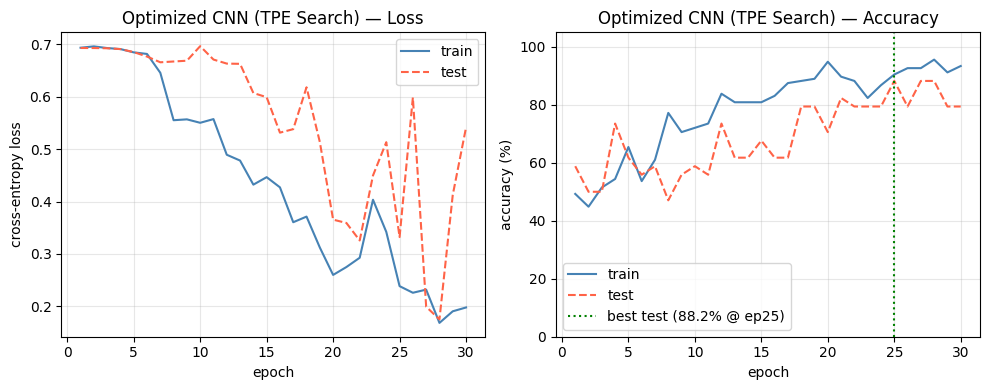

Saved optimized_tpe_search_learning_curves.png


In [66]:
epochs_range = range(1, len(train_loss_history) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Loss curve
ax1.plot(epochs_range, train_loss_history, label="train", color="steelblue")
ax1.plot(epochs_range, test_loss_history,  label="test",  color="tomato", linestyle="--")
ax1.set_xlabel("epoch")
ax1.set_ylabel("cross-entropy loss")
ax1.set_title("Optimized CNN (TPE Search) — Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, [a * 100 for a in train_acc_history], label="train", color="steelblue")
ax2.plot(epochs_range, [a * 100 for a in test_acc_history],  label="test",  color="tomato", linestyle="--")

best_opt_epoch = int(np.argmax(test_acc_history)) + 1
best_opt_acc   = max(test_acc_history) * 100

# Accuracy curve
ax2.axvline(best_opt_epoch, color="green", linestyle=":", linewidth=1.5, 
            label=f"best test ({best_opt_acc:.1f}% @ ep{best_opt_epoch})")
ax2.set_xlabel("epoch")
ax2.set_ylabel("accuracy (%)")
ax2.set_title("Optimized CNN (TPE Search) — Accuracy")
ax2.set_ylim(0, 105)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../optimized_tpe_search_learning_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved optimized_tpe_search_learning_curves.png")